In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#ucčitavanje podataka
df = pd.read_csv(
    "LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",
)

C:\Users\lovro\AppData\Local\Temp\ipykernel_23792\1755834526.py:2: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [3]:
# from numpy import NaN

# df['Order Date_temp'] = pd.to_datetime(df['Order Date'], errors='coerce')

# valid_date_rows = df[~df['Order Date_temp'].isna()]

# min_total = valid_date_rows["Order Date_temp"].min()


# people = df["CustomerID"].unique()

# data_points = np.zeros((people.shape[0], 10))


# for i, person in enumerate(people):
    
#     n = 0
#     while n == 0 :
#         person_data = df[df["CustomerID"] == person]
#         n = person_data.shape[0]

#     person_data['Order Date_temp'] = pd.to_datetime(person_data['Order Date'], errors='coerce')

#     invalid_date_rows = person_data[person_data['Order Date_temp'].isna()]
#     m = len(invalid_date_rows)
#     n = person_data.shape[0]

#     if m == 0:
#         min,max = person_data["Order Date"].min(), person_data["Order Date"].max()
#         date1 = pd.to_datetime(min)
#         date2 = pd.to_datetime(max)
#         days_diff = (date2 - date1).days
#         last_order = (date1 - min_total).days
#     else:
#         days_diff = NaN
#         last_order = NaN


#     avg_price = person_data["Invoiced price"].mean()
#     avg_count_ordered = person_data["Ordered qty"].mean()
#     avg_count_delivered = person_data["Invoiced qty (shipped)"].mean()

#     corr_price_ordered = person_data["Invoiced price"].corr(person_data["Ordered qty"])
#     corr_price_delivered = person_data["Invoiced price"].corr(person_data["Invoiced qty (shipped)"])
#     corr_qty = person_data["Ordered qty"].corr(person_data["Invoiced qty (shipped)"])

#     gm = person_data["GM%"].mean()
#     data_points[i] = [days_diff, last_order, n, avg_price, avg_count_ordered, avg_count_delivered,
#                       corr_price_ordered, corr_price_delivered, corr_qty, gm]               

In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



def remove_outliers_iqr(df, columns=None, multiplier=1.5):
    """
    uklanja retke koji imaju outlier prema IQR metodi
    gledaju se outlieri po stupcima columns
    """
    if columns is None:
        columns = df.columns
    
    df_clean = df.copy()
    outliers_mask = pd.Series(False, index=df.index)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers_mask = outliers_mask | col_outliers
        
        print(f"{col}: {col_outliers.sum()} outliers ({col_outliers.sum()/len(df)*100:.1f}%)")
    
    print(f"\nTotal rows before removal: {len(df)}")
    print(f"Total outliers: {outliers_mask.sum()} ({outliers_mask.sum()/len(df)*100:.1f}%)")
    
    df_clean = df[~outliers_mask]
    print(f"Total rows after removal: {len(df_clean)}")
    
    return df_clean, outliers_mask


In [5]:
#ovdje gledamo koliko svaki covjek/kompanija je napravio narudžbi i po toj mjeri micemo outliere, njih je 1%, njih posebno hendlat

n_orders_per_customer = df.groupby('CustomerID').size().reset_index(name='n_orders')
high_volume_threshold = n_orders_per_customer['n_orders'].quantile(0.99)  # Top 1%
high_volume_customers = n_orders_per_customer[
    n_orders_per_customer['n_orders'] > high_volume_threshold
]['CustomerID'].tolist()

print(f"High-volume customers (>{high_volume_threshold:.0f} orders): {len(high_volume_customers)} ({len(high_volume_customers)/len(n_orders_per_customer)*100:.1f}%)")

# Separate them
df_high_volume = df[df['CustomerID'].isin(high_volume_customers)]
df_regular = df[~df['CustomerID'].isin(high_volume_customers)]

High-volume customers (>1680 orders): 123 (1.0%)


In [6]:
import numpy as np
import pandas as pd
from numpy import NaN
from sklearn.impute import SimpleImputer

def imputing(df):
    """
    vraca data points dta frame i np  array
    svaki redak je 10 mjera koje se izračunaju za neku osobu 
    mogli bismo i neke druge mjere, ove sam ja tako, po svojoj procjeni stavio, koje su mi se činile bitne

    """
    df['Order Date_temp'] = pd.to_datetime(df['Order Date'], errors='coerce')

    valid_date_rows = df[~df['Order Date_temp'].isna()]

    min_total = valid_date_rows["Order Date_temp"].min() # tu dobijemo najstariju kupovinu ukupno


    people = df["CustomerID"].unique()
    print(f"Total unique customers: {len(people)}")
    data_points = np.zeros((people.shape[0], 10))

    for i, person in enumerate(people): # iteriramo po svim ljudima
        
        
        person_data = df[df["CustomerID"] == person].copy()  
        
        n = person_data.shape[0]
        
        person_data['Order Date_temp'] = pd.to_datetime(person_data['Order Date'], errors='coerce')
        
        # gledamo datuma koji nisu ispravno upisani ili nedostaju
        invalid_date_rows = person_data[person_data['Order Date_temp'].isna()]
        m = len(invalid_date_rows)
        

        # u ovom bloku racunamo učestalost(frequency) kupovine, i posljednji put kada je osoba kupovala
        if m == 0 and n > 0:  
            try:
                min_date = person_data["Order Date_temp"].min()
                max_date = person_data["Order Date_temp"].max()
                
                if pd.notna(min_date) and pd.notna(max_date):
                    days_diff = (max_date - min_date).days
                    last_order = (min_date - min_total).days
                else:
                    days_diff = np.nan
                    last_order = np.nan
            except:
                days_diff = np.nan
                last_order = np.nan
        else:
            days_diff = np.nan
            last_order = np.nan
        
        
        #računamo prosječnu cijenu, brojnaručenih predmeta i broj dostavljenih predmeta
        avg_price = person_data["Invoiced price"].mean(skipna=True)
        avg_count_ordered = person_data["Ordered qty"].mean(skipna=True)
        avg_count_delivered = person_data["Invoiced qty (shipped)"].mean(skipna=True)
        
        #blok računa korelaciju broja naručenih podataka i cijene
        valid_pairs_price_ordered = person_data[["Invoiced price", "Ordered qty"]].dropna().shape[0]
        if valid_pairs_price_ordered >= 3:  # zahtjevamo barem tri podatka za korelaciju
            corr_price_ordered = person_data["Invoiced price"].corr(person_data["Ordered qty"])
        else:
            corr_price_ordered = np.nan
        
        
        #blok računa korelaciju broja dostavljenih podataka i cijene
        valid_pairs_price_delivered = person_data[["Invoiced price", "Invoiced qty (shipped)"]].dropna().shape[0]
        if valid_pairs_price_delivered >= 3:  # zahtjevamo barem tri podatka za korelaciju
            corr_price_delivered = person_data["Invoiced price"].corr(person_data["Invoiced qty (shipped)"])
        else:
            corr_price_delivered = np.nan
        
        
        #blok računa korelaciju broja naručenih podataka i broja dostavljenih
        valid_pairs_qty = person_data[["Ordered qty", "Invoiced qty (shipped)"]].dropna().shape[0]
        if valid_pairs_qty >= 3:  # zahtjevamo barem tri podatka za korelaciju
            corr_qty = person_data["Ordered qty"].corr(person_data["Invoiced qty (shipped)"])
        else:
            corr_qty = np.nan
        
        
        #sprema gm% to je u biti zarada: (prodajna cijena-cijena)/prodajna cijena 
        gm_data = person_data["GM%"].dropna()
        if len(gm_data) >= 3:
            gm = gm_data.mean()
        else:
            gm = np.nan
        
        # popuniti sve s nan
        data_points[i] = [days_diff if not pd.isna(days_diff) else np.nan,
                        last_order if not pd.isna(last_order) else np.nan,
                        n,
                        avg_price if not pd.isna(avg_price) else np.nan,
                        avg_count_ordered if not pd.isna(avg_count_ordered) else np.nan,
                        avg_count_delivered if not pd.isna(avg_count_delivered) else np.nan,
                        corr_price_ordered,  # Already handled NaN
                        corr_price_delivered,  # Already handled NaN
                        corr_qty,  # Already handled NaN
                        gm if not pd.isna(gm) else np.nan]

    # After building data_points, impute remaining NaNs with median
    print(f"NaN counts before imputation:")
    print(pd.DataFrame(data_points).isna().sum())

    # median imputer
    imputer = SimpleImputer(strategy='median')
    data_points_imputed = imputer.fit_transform(data_points)

    print(f"\nNaN counts after imputation:")
    print(pd.DataFrame(data_points_imputed).isna().sum())

    # genreira dataframe od podatka
    column_names = ['days_diff', 'last_order', 'n_orders', 'avg_price', 
                    'avg_ordered_qty', 'avg_delivered_qty',
                    'corr_price_ordered', 'corr_price_delivered', 
                    'corr_qty', 'gm']

    data_points_imputed_df = pd.DataFrame(data_points_imputed, columns=column_names)

    return data_points_imputed_df, data_points_imputed
# Example of running k-means on the imputed data:
# from sklearn.cluster import KMeans
# kmeans = KMeans(n_clusters=3, random_state=42)
# clusters = kmeans.fit_predict(data_points_imputed)

In [7]:
a = np.unique(df_regular['CustomerID'])
a.shape

(12091,)

In [8]:
data_points_imputed_df, data_points_imputed = imputing(df_regular)       

C:\Users\lovro\AppData\Local\Temp\ipykernel_23792\3627917599.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order Date_temp'] = pd.to_datetime(df['Order Date'], errors='coerce')


Total unique customers: 12091
NaN counts before imputation:
0    1576
1    1576
2       0
3       5
4      74
5       0
6    5010
7    4806
8    4633
9    4263
dtype: int64

NaN counts after imputation:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64


(12091, 10)

In [10]:

# Remove outliers
columns_for_outlier_removal = ['avg_price', 'avg_ordered_qty', 'avg_delivered_qty', 
                                'days_diff', 'gm']  # Choose relevant columns


# ovaj dio makne pola podataka
#df_clean, outlier_mask = remove_outliers_iqr(data_points_imputed_df, columns_for_outlier_removal)


In [22]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_points_imputed_df)



KMeans(n_clusters=10, n_init=10, random_state=42)

In [44]:
k = 2 
min_size = 100

N = data_scaled.shape[0]


# Track original indices
active_idx = np.arange(N)
removed_idx = np.array([], dtype=int)

while True:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled[active_idx])
    
    labels = kmeans.labels_
    unique, counts = np.unique(labels, return_counts=True)
    
    small_clusters = unique[counts < min_size]
    
    if len(small_clusters) == 0:
        break
    
    mask_small = np.isin(labels, small_clusters)
    
    # Move small cluster indices to removed
    removed_idx = np.concatenate([removed_idx, active_idx[mask_small]])
    
    # Keep only large clusters
    active_idx = active_idx[~mask_small]

# Final clustering on surviving points
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(data_scaled[active_idx])

final_labels_active = kmeans.labels_

# Assign removed points to nearest centroid
if len(removed_idx) == 0:
    final_labels = np.empty(N, dtype=int)
    final_labels[active_idx] = final_labels_active
else:
    removed_points = data_scaled[removed_idx]
    distances = kmeans.transform(removed_points)
    final_labels_removed = np.argmin(distances, axis=1)

    # Construct final label array
    final_labels = np.empty(N, dtype=int)
    final_labels[active_idx] = final_labels_active
    final_labels[removed_idx] = final_labels_removed


In [54]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sklearn_silhouette_score
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_points_imputed_df)
min_size = 100

def adjusted_kmeans(data_scaled, k, min_size=100):
    N = data_scaled.shape[0]


    # Track original indices
    active_idx = np.arange(N)
    removed_idx = np.array([], dtype=int)

    while True:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data_scaled[active_idx])
        
        labels = kmeans.labels_
        unique, counts = np.unique(labels, return_counts=True)
        
        small_clusters = unique[counts < min_size]
        
        if len(small_clusters) == 0:
            break
        
        mask_small = np.isin(labels, small_clusters)
        
        # Move small cluster indices to removed
        removed_idx = np.concatenate([removed_idx, active_idx[mask_small]])
        
        # Keep only large clusters
        active_idx = active_idx[~mask_small]

    # Final clustering on surviving points
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled[active_idx])

    final_labels_active = kmeans.labels_

    # Assign removed points to nearest centroid
    if len(removed_idx) == 0:
        final_labels = np.empty(N, dtype=int)
        final_labels[active_idx] = final_labels_active
    else:
        removed_points = data_scaled[removed_idx]
        distances = kmeans.transform(removed_points)
        final_labels_removed = np.argmin(distances, axis=1)

        # Construct final label array
        final_labels = np.empty(N, dtype=int)
        final_labels[active_idx] = final_labels_active
        final_labels[removed_idx] = final_labels_removed

    return final_labels, active_idx, removed_idx

In [38]:
import numpy as np

def metrics(data_points, labels):
    k = labels.max() + 1
    
    # Compute centroids
    centroids = np.vstack([
        data_points[labels == i].mean(axis=0)
        for i in range(k)
    ])
    
    # Silhouette
    silhouette = sklearn_silhouette_score(data_points, labels)
    
    # Mean distance to assigned centroid
    mean_centroid_distance = np.mean(
        np.linalg.norm(data_points - centroids[labels], axis=1)
    )
    
    return silhouette, mean_centroid_distance

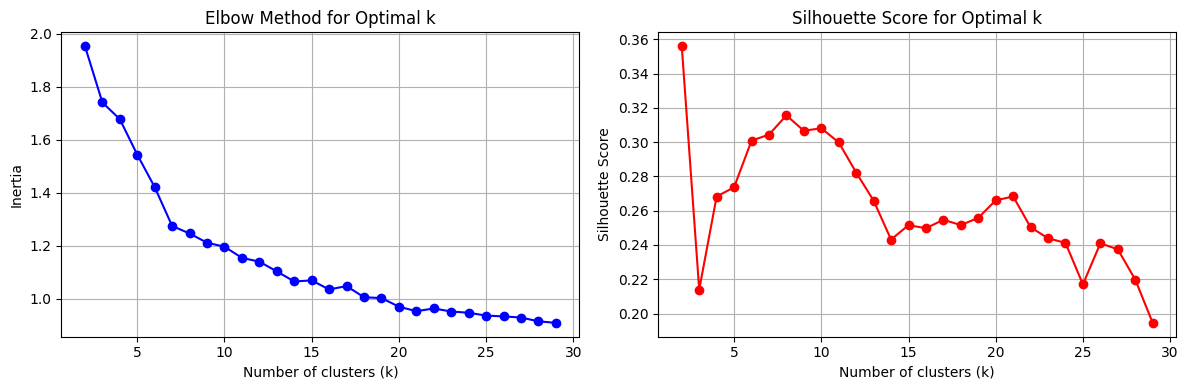

k=2: Silhouette Score = 0.3560
k=3: Silhouette Score = 0.2140
k=4: Silhouette Score = 0.2683
k=5: Silhouette Score = 0.2736
k=6: Silhouette Score = 0.3008
k=7: Silhouette Score = 0.3043
k=8: Silhouette Score = 0.3156
k=9: Silhouette Score = 0.3066
k=10: Silhouette Score = 0.3081
k=11: Silhouette Score = 0.2998
k=12: Silhouette Score = 0.2822
k=13: Silhouette Score = 0.2658
k=14: Silhouette Score = 0.2432
k=15: Silhouette Score = 0.2515
k=16: Silhouette Score = 0.2498
k=17: Silhouette Score = 0.2547
k=18: Silhouette Score = 0.2516
k=19: Silhouette Score = 0.2558
k=20: Silhouette Score = 0.2660
k=21: Silhouette Score = 0.2683
k=22: Silhouette Score = 0.2503
k=23: Silhouette Score = 0.2439
k=24: Silhouette Score = 0.2412
k=25: Silhouette Score = 0.2170
k=26: Silhouette Score = 0.2410
k=27: Silhouette Score = 0.2374
k=28: Silhouette Score = 0.2198
k=29: Silhouette Score = 0.1945


In [55]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

"""
 tu se računa klasični k means i silouhette score(to nisam ziher kaj je to je chat dao) 
 za raličit broj clustera da se odredi optimalni k
"""

column_names = ['days_diff', 'last_order', 'n_orders', 'avg_price', 
                'avg_ordered_qty', 'avg_delivered_qty',
                'corr_price_ordered', 'corr_price_delivered', 
                'corr_qty', 'gm']


# 2. Scale the data (crucial for k-means!)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_points_imputed_df)

# 3. Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 30)

for k in K_range:
    """
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    silhouette_score, inertia = metrics(data_scaled, kmeans.labels_)
    """
    #ovo je adjusted k means koji uvijek daje clustere koji imaju barem 100 članova
    final_labels, active_idx, removed_idx = adjusted_kmeans(data_scaled,k, min_size=100)
    silhouette_score, inertia = metrics(data_scaled, final_labels)
    
    inertias.append(inertia)
    silhouette_scores.append(silhouette_score)

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow method plot
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Print silhouette scores
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: Silhouette Score = {score:.4f}")

# 4. Choose optimal k (let's say based on silhouette score)


In [13]:
data_scaled.shape

(12091, 10)

In [56]:
cluster_labels, active_idx, removed_idx = adjusted_kmeans(data_scaled, 7, min_size=100)
np.unique(cluster_labels)

array([0, 1, 2, 3, 4, 5, 6])


Optimal number of clusters: 8
(12091, 10)

=== Cluster Analysis ===

Cluster sizes:
0    1733
1    2241
2     820
3    2324
4     321
5     993
6     163
7    3496
Name: Cluster, dtype: int64

Cluster means (scaled back to original units):
          days_diff   last_order    n_orders    avg_price  avg_ordered_qty  \
Cluster                                                                      
0        432.811887  6922.372764   11.836699   314.511642     3.190834e+03   
1        819.275324  6744.863454   71.493083   589.131245     6.539947e+03   
2        433.268293  6930.054878   16.242683   435.836308     4.717030e+03   
3         43.495267  7430.729346    5.876076   985.959262     1.974106e+03   
4        971.342679  6653.713396  824.383178  2772.700911     2.582696e+05   
5        542.944612  6857.770393   56.741188   320.895534     1.585811e+04   
6        489.564417  6843.030675   85.190184    85.422627     1.082198e+06   
7        167.706236  6910.082094   10.357551   789.509009

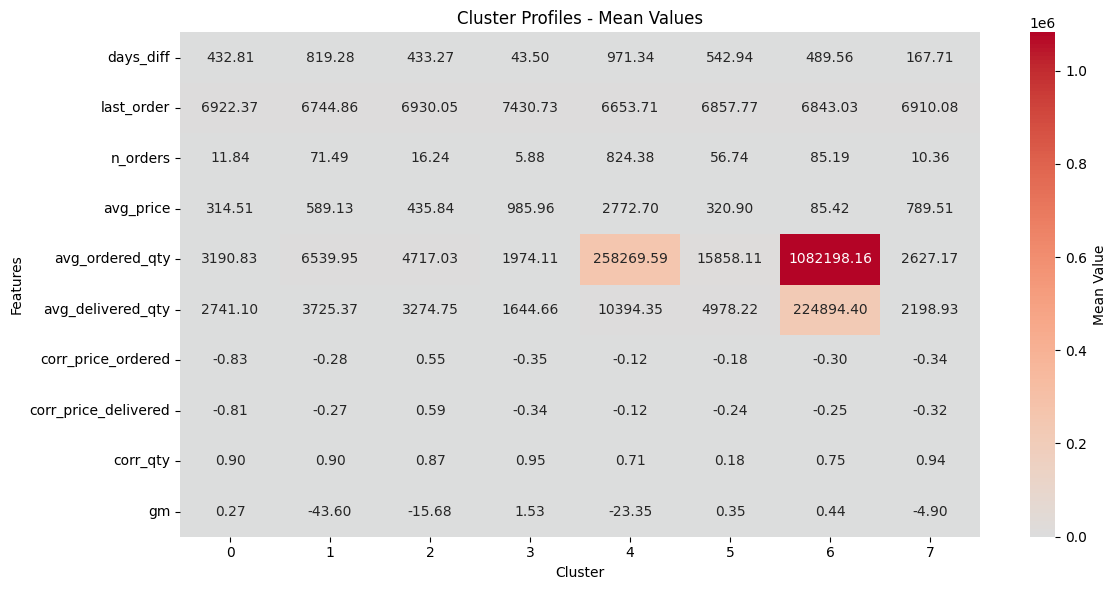

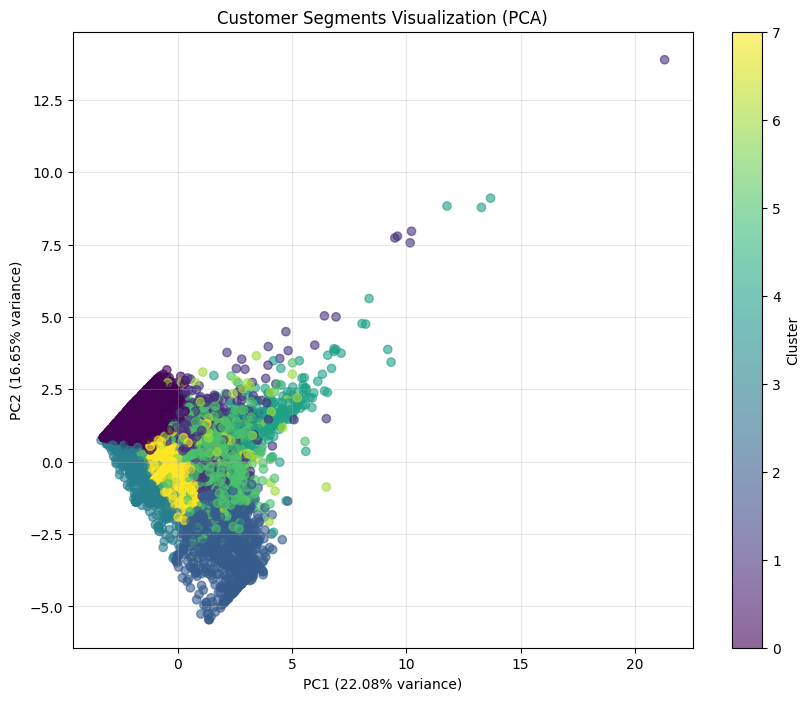


Cluster Centers (original units):
    days_diff   last_order    n_orders    avg_price  avg_ordered_qty  \
0   85.461796  7164.804324    6.112188   888.034177     2.476935e+03   
1  671.826502  6794.748110  171.871866   724.854569     3.015141e+04   
2  837.500000  6797.000000  295.250000     4.189625     4.792849e+07   
3  572.526266  6828.287854   26.826242   452.396802     7.630228e+03   
4  611.000000  6703.000000   20.000000  6779.501500     2.650000e+00   

   avg_delivered_qty  corr_price_ordered  corr_price_delivered  corr_qty  \
0        2177.537031           -0.354315             -0.332711  0.948072   
1       13802.795445            0.131367              0.112119  0.634266   
2       16032.308925           -0.199129             -0.330978  0.356920   
3        6131.768889           -0.549817             -0.534938  0.857692   
4           1.800000           -0.258198             -0.151291  0.888082   

             gm  
0      0.886518  
1     -8.248282  
2      0.331264  
3  

In [58]:
# odabrao sam 11 tu sad dalje ide neka analiza i vizualizacija
optimal_k = 8
print(f"\nOptimal number of clusters: {optimal_k}")

print(data_scaled.shape)

# ovo je klasicni kmeans
"""
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(data_scaled)
"""
#ovo je adjusted k means koji uvijek daje clustere koji imaju barem 100 članova
cluster_labels, active_idx, removed_idx = adjusted_kmeans(data_scaled, optimal_k, min_size=100)


# Add cluster labels to your dataframe
labeled_data_points_imputed_df = data_points_imputed_df.copy()
labeled_data_points_imputed_df['Cluster'] = cluster_labels

# 6. Analyze cluster characteristics
print("\n=== Cluster Analysis ===")
print("\nCluster sizes:")
print(labeled_data_points_imputed_df['Cluster'].value_counts().sort_index())

# Calculate mean values for each cluster
cluster_means = labeled_data_points_imputed_df.groupby('Cluster').mean()
print("\nCluster means (scaled back to original units):")
print(cluster_means)

# 7. Visualize cluster profiles
# Create a heatmap of cluster characteristics
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', cbar_kws={'label': 'Mean Value'})
plt.title('Cluster Profiles - Mean Values')
plt.ylabel('Features')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# 8. Visualize clusters using PCA for 2D visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Customer Segments Visualization (PCA)')
plt.grid(True, alpha=0.3)
plt.show()

# 9. Analyze feature importance for clustering
# Look at cluster centers
cluster_centers = scaler.inverse_transform(final_kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=column_names)
print("\nCluster Centers (original units):")
print(cluster_centers_df)

# 10. Save results
labeled_data_points_imputed_df.to_csv('customer_clusters.csv', index=False)
print("\nResults saved to 'customer_clusters.csv'")

# 11. Optional: Characterize each cluster
print("\n=== Cluster Characterization ===")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} (n={sum(cluster_labels==cluster)} customers):")
    cluster_data = labeled_data_points_imputed_df[labeled_data_points_imputed_df['Cluster'] == cluster]
    
    # Print key characteristics
    print(f"  Average days between orders: {cluster_data['days_diff'].mean():.1f}")
    print(f"  Average order value: ${cluster_data['avg_price'].mean():.2f}")
    print(f"  Average order quantity: {cluster_data['avg_ordered_qty'].mean():.1f}")
    print(f"  Average GM%: {cluster_data['gm'].mean():.1f}%")
    print(f"  Price-Order correlation: {cluster_data['corr_price_ordered'].mean():.3f}")

In [15]:
"""
postoje invoice price 0 narudzbe, onda gm% bude nan i nemogu korelaciju gledati
ponekad je inovice price 0, a product cost nije, mogao bih onda gm% postaviti na -max
order qty i deliver qty se razlikuju
invoice dateovi neki su invalidni


nisam zadovoljan sve skupa jer postoje klasteri s po jednom osobom, možda su to ovi izdvojeni iz skupine na slici
"""

'\npostoje invoice price 0 narudzbe, onda gm% bude nan i nemogu korelaciju gledati\nponekad je inovice price 0, a product cost nije, mogao bih onda gm% postaviti na -max\norder qty i deliver qty se razlikuju\ninvoice dateovi neki su invalidni\n\n\nnisam zadovoljan sve skupa jer postoje klasteri s po jednom osobom, možda su to ovi izdvojeni iz skupine na slici\n'